In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)

`pyringdown` has both time- and frequency-domain waveform interfaces. At the base level are Python functions:

In [2]:
from pyringdown.waveform.td import small_angle

small_angle.parameters  # view the parameters

['A', 'gamma', 'f_N', 'phi0']

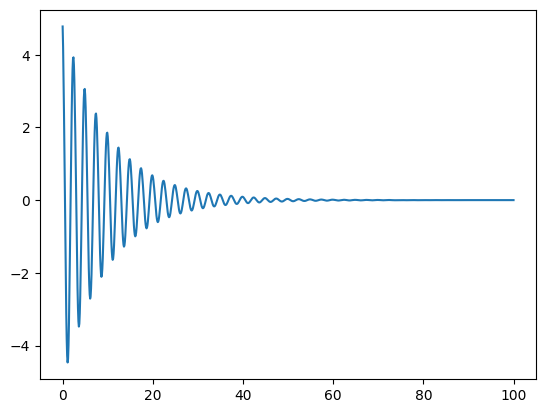

In [3]:
t = np.linspace(0,100,1001)
waveform = small_angle(t, dict(A=5, gamma=0.1, f_N=0.4,phi0=0.3))
plt.plot(t, waveform)

For convenience, waveform classes are also provided, that allow for easier cross-domain generation. Frequency-domain waveforms are not exact and so some ringing can be expected in the time domain.

In [6]:
from pyringdown.waveform.interface import TDWaveform, FDWaveform
from pyringdown.waveform.fd import small_angle as fd_small_angle

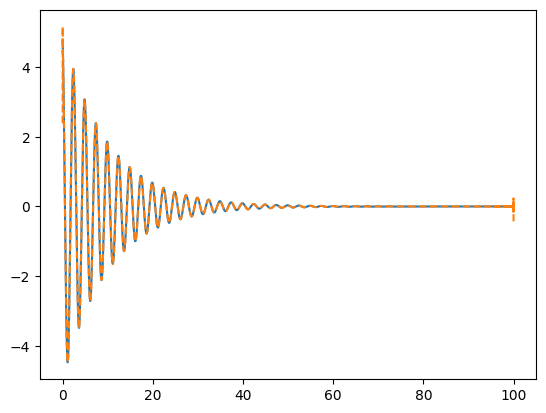

In [16]:
wf_td = TDWaveform(small_angle, dt=1e-2, T=1e2)
wf_fd = FDWaveform(fd_small_angle, df=1e-2, f_max=50.0)

parameters = dict(A=5, gamma=0.1, f_N=0.4,phi0=0.3)

td_wave = wf_td.get_td_waveform(parameters)
fd_to_td_wave = wf_fd.get_td_waveform(parameters)
plt.plot(wf_td.t, td_wave)
plt.plot(wf_td.t, fd_to_td_wave, '--')

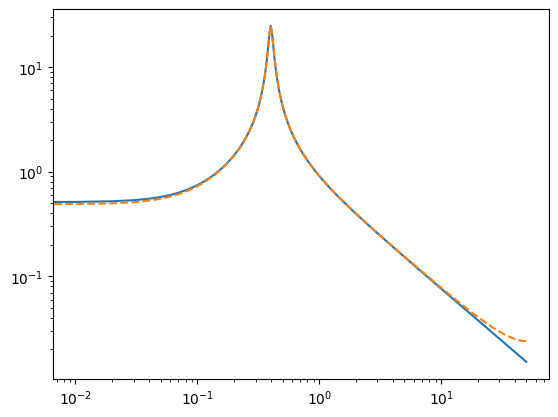

In [21]:
td_to_fd_wave = wf_td.get_fd_waveform(parameters)
fd_wave = wf_fd.get_fd_waveform(parameters)
plt.loglog(wf_fd.f, np.abs(fd_wave))
plt.loglog(wf_fd.f, np.abs(td_to_fd_wave), '--')

Frequency-domain waveforms can also be generated on a reduced grid if required:

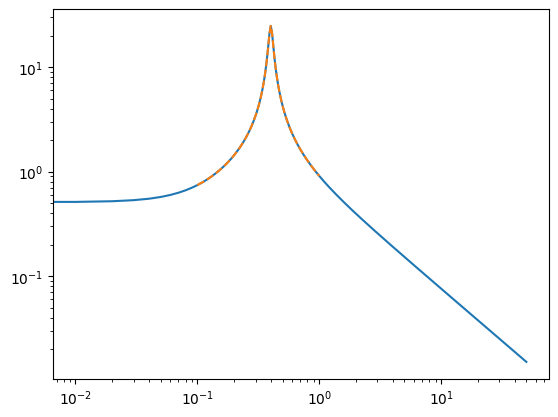

In [26]:
wf_fd_trunc = FDWaveform(fd_small_angle, df=1e-2, f_min = 0.1, f_max=1.0)

fd_wave = wf_fd.get_fd_waveform(parameters)
fd_wave_trunc = wf_fd_trunc.get_fd_waveform(parameters)

plt.loglog(wf_fd.f, np.abs(fd_wave))
plt.loglog(wf_fd_trunc.f, np.abs(fd_wave_trunc), '--')

Finally, as these waveforms are JAX-compatible, they are amenable to `vmap` or `grad` operations if required.

(4, 10000)

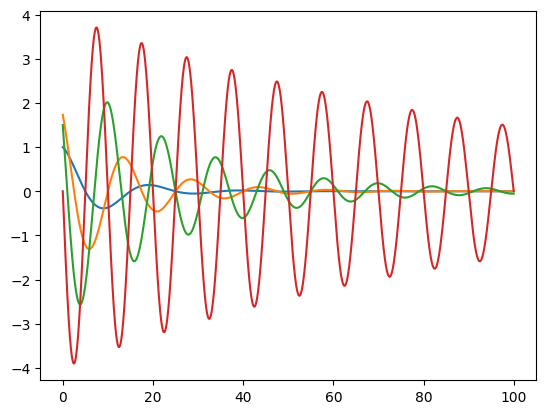

In [38]:
import jax.numpy as jnp

params = dict(
    A = jnp.arange(4) + 1,
    gamma = jnp.linspace(0.1, 0.01, 4),
    f_N = jnp.linspace(0.05, 0.1, 4),
    phi0 = jnp.linspace(0, jnp.pi/2, 4),
)

td_waves = jax.vmap(wf_td.get_td_waveform)(params)

plt.plot(wf_td.t, td_waves.T)
td_waves.shape